# 🌫️ PM2.5 Spike Prediction — LightGBM Multi-Horizon Classifier

This notebook trains **three binary classifiers** (one per forecast horizon: **t+1h, t+2h, t+3h**) to predict PM2.5 pollution spikes across Bangladesh monitoring stations.

**Pipeline overview:**
1. Load pre-engineered train/test feature CSVs  
2. Apply SMOTE oversampling to handle severe class imbalance (~1% spike rate)  
3. Train a LightGBM classifier with early stopping  
4. Evaluate with F1, Recall, Precision, ROC-AUC, PR-AUC  
5. Visualise confusion matrices, metric comparisons, and SHAP feature importance inline  

## 1. Imports & Configuration

In [23]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868']  # one colour per horizon
print('✅ Imports done')

✅ Imports done


## 2. Path & Hyperparameter Configuration

In [24]:
TRAIN_PATH  = 'train_features_v3.csv'
TEST_PATH   = 'test_features_v3.csv'
HORIZONS    = [1, 2, 3]
USE_SMOTE   = False         # set True only if you explicitly want SMOTE instead of class weighting
MODELS_DIR  = 'models'
SHAP_DIR    = 'shap_plots'
TRAIN_SPLIT = 0.8           # chronological train/val split inside training data
THRESHOLD_GRID = np.linspace(0.10, 0.90, 161)
RECALL_FLOOR = 0.75

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SHAP_DIR,   exist_ok=True)

# Columns excluded from features (identifiers / raw targets / already encoded)
NON_FEATURE_COLS = [
    'No', 'year', 'month', 'day', 'hour', 'wd', 'datetime',
    'spike_t+1', 'spike_t+2', 'spike_t+3',
]


def add_advanced_horizon_features(df):
    """Add long-horizon, station-local, and neighbor-aware signals for better spike detection."""
    df = df.sort_values(['station', 'datetime']).copy()

    df['pm25_delta_1'] = df['PM2.5'] - df.groupby('station')['PM2.5'].shift(1)
    df['pm25_delta_3'] = df['PM2.5'] - df.groupby('station')['PM2.5'].shift(3)
    df['pm25_change_6'] = df['PM2.5'] - df.groupby('station')['PM2.5'].shift(6)
    df['pm25_roc_3'] = df['pm25_delta_3'] / 3.0

    if 'pm25_roll_mean_6' in df.columns:
        df['pm25_trend_6'] = df['PM2.5'] - df['pm25_roll_mean_6']

    if 'idw_pm25_neighbors' in df.columns:
        df['pm25_vs_neighbor'] = df['PM2.5'] - df['idw_pm25_neighbors']
        df['neighbor_pressure'] = df['idw_pm25_neighbors'] / (df['PM2.5'] + 1e-6)

    if 'dayofweek' in df.columns:
        df['weekend_flag'] = df['dayofweek'].isin([5, 6]).astype(int)

    station_mean = df.groupby('station')['PM2.5'].transform(
        lambda s: s.rolling(24, min_periods=12).mean()
    )
    station_std = df.groupby('station')['PM2.5'].transform(
        lambda s: s.rolling(24, min_periods=12).std().fillna(0.0)
    )
    df['station_pm25_zscore_24'] = (df['PM2.5'] - station_mean) / station_std.replace(0, np.nan)
    df['station_pm25_zscore_24'] = df['station_pm25_zscore_24'].fillna(0.0)

    if 'regional_elevated_frac' in df.columns:
        df['regional_gap'] = df['PM2.5'] - df['regional_elevated_frac']
    else:
        df['regional_gap'] = 0.0

    return df


if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    train_v2 = pd.read_csv('train_features_v2.csv')
    test_v2 = pd.read_csv('test_features_v2.csv')
    train_v3 = add_advanced_horizon_features(train_v2)
    test_v3 = add_advanced_horizon_features(test_v2)
    train_v3.to_csv(TRAIN_PATH, index=False)
    test_v3.to_csv(TEST_PATH, index=False)
    print(f'✅ Created enhanced feature files: {TRAIN_PATH}, {TEST_PATH}')

print('✅ Configuration set')

✅ Configuration set


## 3. Data Loading

We use the **v2 feature CSVs** produced by notebook `3_feature_engineering.ipynb`.  
An 80/20 chronological split is applied so that validation always comes *after* training — preventing temporal leakage.

In [25]:
def load_data():
    train = pd.read_csv(TRAIN_PATH)
    test  = pd.read_csv(TEST_PATH)
    train = add_advanced_horizon_features(train)
    test  = add_advanced_horizon_features(test)
    train['datetime'] = pd.to_datetime(train['datetime'])
    test['datetime']  = pd.to_datetime(test['datetime'])
    return train, test

train_full, test = load_data()

# Chronological split
split = int(len(train_full) * TRAIN_SPLIT)
train = train_full.iloc[:split].copy()
valid = train_full.iloc[split:].copy()

print(f'Train rows : {len(train):,}')
print(f'Valid rows : {len(valid):,}')
print(f'Test  rows : {len(test):,}')
print(f"Date range (train): {train['datetime'].min().date()} to {train['datetime'].max().date()}")
print(f"Date range (valid): {valid['datetime'].min().date()} to {valid['datetime'].max().date()}")
train_full.head(3)

Train rows : 143,424
Valid rows : 35,856
Test  rows : 28,800
Date range (train): 2022-08-05 to 2025-12-31
Date range (valid): 2022-08-05 to 2025-12-31


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,pm25_delta_1,pm25_delta_3,pm25_change_6,pm25_roc_3,pm25_trend_6,pm25_vs_neighbor,neighbor_pressure,weekend_flag,station_pm25_zscore_24,regional_gap
0,173665,2022,8,5,0,8.5,13.5,1.0,3.1,118.0,...,NaN,NaN,NaN,NaN,1.183333,-3.969896,1.467046,0,0.0,8.5
1,173666,2022,8,5,1,7.1,11.5,1.1,2.9,119.0,...,-1.4,NaN,NaN,NaN,-0.316667,-3.408043,1.480006,0,0.0,7.1
2,173667,2022,8,5,2,6.4,10.3,1.1,2.7,120.0,...,-0.7,NaN,NaN,NaN,-0.916667,-1.798478,1.281012,0,0.0,6.4


### 3.1 Class Imbalance Check

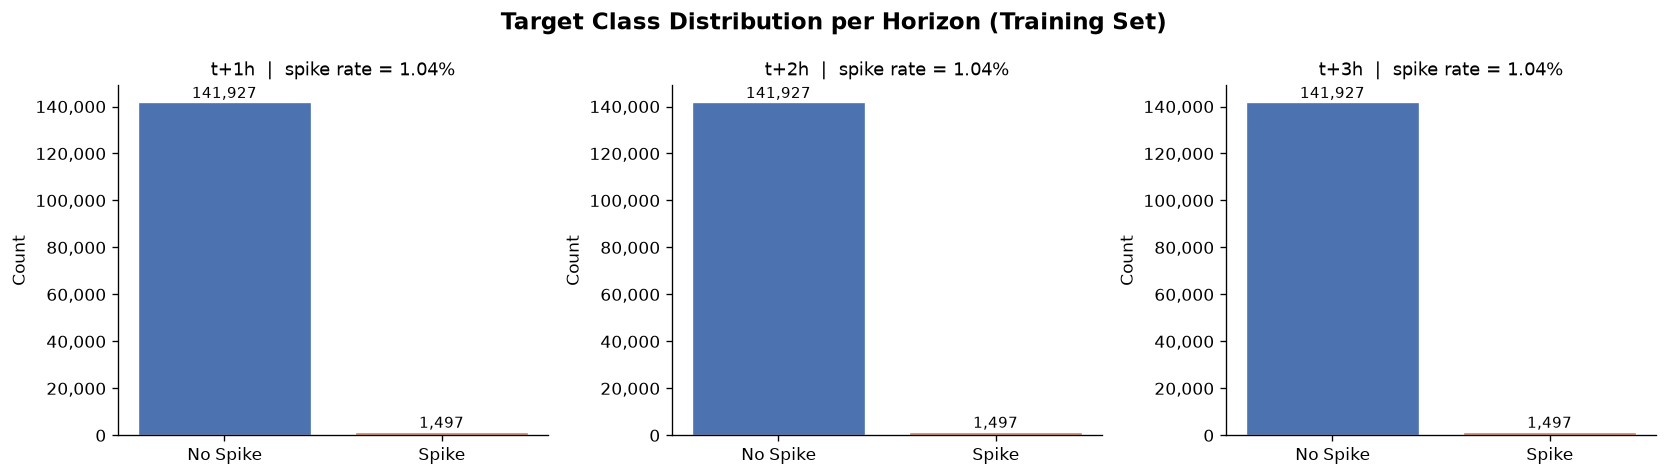

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.suptitle('Target Class Distribution per Horizon (Training Set)', fontsize=14, fontweight='bold')

for ax, h in zip(axes, HORIZONS):
    col = f'spike_t+{h}'
    counts = train[col].value_counts().sort_index()
    bars = ax.bar(['No Spike', 'Spike'], counts.values,
                  color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=0.8)
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{cnt:,}', ha='center', va='bottom', fontsize=9)
    rate = counts.get(1, 0) / counts.sum() * 100
    ax.set_title(f't+{h}h  |  spike rate = {rate:.2f}%', fontsize=11)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 4. Helper Functions

In [27]:
def get_feature_cols(df):
    return [c for c in df.columns if c not in NON_FEATURE_COLS]


def prep_xy(df, feature_cols, target_col=None):
    X = df[feature_cols].copy()
    X['station'] = X['station'].astype('category')
    y = None
    if target_col is not None and target_col in df.columns:
        y = df[target_col].astype(int)
    return X, y


def get_best_threshold(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLD_GRID

    best_threshold = 0.5
    best_f1 = -1.0
    best_recall = -1.0
    best_precision = -1.0
    best_score = -1.0

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)

        if recall < RECALL_FLOOR:
            continue

        score = (0.7 * f1) + (0.3 * recall)
        if score > best_score or (np.isclose(score, best_score) and f1 > best_f1):
            best_threshold = float(thr)
            best_f1 = float(f1)
            best_recall = float(recall)
            best_precision = float(precision)
            best_score = float(score)

    if best_score < 0:
        for thr in thresholds:
            y_pred = (y_proba >= thr).astype(int)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            precision = precision_score(y_true, y_pred, zero_division=0)

            if (f1 > best_f1) or (np.isclose(f1, best_f1) and recall > best_recall):
                best_threshold = float(thr)
                best_f1 = float(f1)
                best_recall = float(recall)
                best_precision = float(precision)
                best_score = float(f1)

    return best_threshold, best_f1, best_recall, best_precision


def train_one_horizon(train_df, val_df, horizon):
    """Train LightGBM for one horizon using validation-driven threshold tuning."""
    target_col = f'spike_t+{horizon}'
    feature_cols = get_feature_cols(train_df)

    X_train, y_train = prep_xy(train_df, feature_cols, target_col)
    X_val, y_val = prep_xy(val_df, feature_cols, target_col)

    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    if USE_SMOTE:
        X_ohe = pd.get_dummies(X_train, columns=['station'])
        sm = SMOTE(random_state=42, k_neighbors=5)
        X_res, y_res = sm.fit_resample(X_ohe, y_train)
        sta_cols = [c for c in X_res.columns if c.startswith('station_')]
        X_res['station'] = (
            X_res[sta_cols].idxmax(axis=1).str.replace('station_', '', regex=False)
        )
        X_res = X_res.drop(columns=sta_cols)
        X_res['station'] = X_res['station'].astype('category')
        print(f'  SMOTE → {len(X_res):,} rows, spike rate={y_res.mean()*100:.2f}%')
        scale_pos_weight = 1.0
    else:
        X_res, y_res = X_train, y_train

    model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1500,
        learning_rate=0.025,
        num_leaves=80,
        min_child_samples=40,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.5,
        max_depth=-1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        feature_fraction_bynode=0.8,
    )
    model.fit(
        X_res,
        y_res,
        categorical_feature=['station'],
        eval_set=[(X_val, y_val)],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(60, verbose=False)],
    )

    y_proba = model.predict_proba(X_val)[:, 1]
    best_threshold, best_f1, best_recall, best_precision = get_best_threshold(y_val, y_proba)
    y_pred = (y_proba >= best_threshold).astype(int)

    metrics = {
        'horizon': horizon,
        'best_threshold': best_threshold,
        'valid_f1': best_f1,
        'valid_recall': best_recall,
        'valid_precision': best_precision,
        'f1': f1_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_val, y_proba),
        'pr_auc': average_precision_score(y_val, y_proba),
    }
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    metrics.update({'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})

    print(f"  Best threshold={best_threshold:.3f} | F1={best_f1:.3f} Recall={best_recall:.3f} Precision={best_precision:.3f}")
    print(f"  Valid F1={metrics['f1']:.3f}  Recall={metrics['recall']:.3f}  "
          f"Precision={metrics['precision']:.3f}  ROC-AUC={metrics['roc_auc']:.3f}  "
          f"PR-AUC={metrics['pr_auc']:.3f}")
    print(f"  Confusion matrix -> TP={tp} FP={fp} FN={fn} TN={tn}")

    joblib.dump(model, f'{MODELS_DIR}/lgbm_spike_t{horizon}.joblib')
    return model, X_val, y_val, metrics, y_proba, best_threshold


print('✅ Helper functions defined')

✅ Helper functions defined


## 5. Training — All Horizons

We loop over **t+1h, t+2h, t+3h** and collect models + evaluation data for later visualisation.

In [28]:
all_metrics = []
models = {}
X_vals = {}
y_vals = {}
y_probas = {}
thresholds = {}

for h in HORIZONS:
    print(f"\n{'='*60}")
    print(f'Training horizon t+{h}h ...')
    model, X_val, y_val, metrics, y_proba, best_thr = train_one_horizon(train, valid, h)
    all_metrics.append(metrics)
    models[h] = model
    X_vals[h] = X_val
    y_vals[h] = y_val
    y_probas[h] = y_proba
    thresholds[h] = best_thr

print(f"\n{'='*60}")
print('✅ All models trained!')


Training horizon t+1h ...
  Best threshold=0.890 | F1=0.864 Recall=0.880 Precision=0.849
  Valid F1=0.864  Recall=0.880  Precision=0.849  ROC-AUC=1.000  PR-AUC=0.931
  Confusion matrix -> TP=73 FP=13 FN=10 TN=35760

Training horizon t+2h ...
  Best threshold=0.435 | F1=0.670 Recall=0.843 Precision=0.556
  Valid F1=0.670  Recall=0.843  Precision=0.556  ROC-AUC=0.999  PR-AUC=0.785
  Confusion matrix -> TP=70 FP=56 FN=13 TN=35717

Training horizon t+3h ...
  Best threshold=0.505 | F1=0.527 Recall=0.771 Precision=0.400
  Valid F1=0.527  Recall=0.771  Precision=0.400  ROC-AUC=0.997  PR-AUC=0.617
  Confusion matrix -> TP=64 FP=96 FN=19 TN=35677

✅ All models trained!


## 6. Results Summary Table

In [29]:
results_df = pd.DataFrame(all_metrics)
results_df.to_csv('model_results.csv', index=False)

display_df = results_df.copy()
display_df['horizon'] = display_df['horizon'].apply(lambda x: f't+{x}h')
for col in ['f1', 'recall', 'precision', 'roc_auc', 'pr_auc']:
    display_df[col] = display_df[col].apply(lambda v: f'{v:.4f}')

print('Model Results Summary:')
display_df.style \
    .set_caption('LightGBM Multi-Horizon PM2.5 Spike Classifier — Evaluation Metrics') \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-weight', 'bold'), ('font-size', '14px')]
    }]) \
    .hide(axis='index')

Model Results Summary:


horizon,best_threshold,valid_f1,valid_recall,valid_precision,f1,recall,precision,roc_auc,pr_auc,tp,fp,fn,tn
t+1h,0.890000,0.863905,0.879518,0.848837,0.8639,0.8795,0.8488,0.9998,0.9310,73,13,10,35760
t+2h,0.435000,0.669856,0.843373,0.555556,0.6699,0.8434,0.5556,0.9990,0.7854,70,56,13,35717
t+3h,0.505000,0.526749,0.771084,0.400000,0.5267,0.7711,0.4000,0.9973,0.6172,64,96,19,35677


## 7. Metric Comparisons Across Horizons

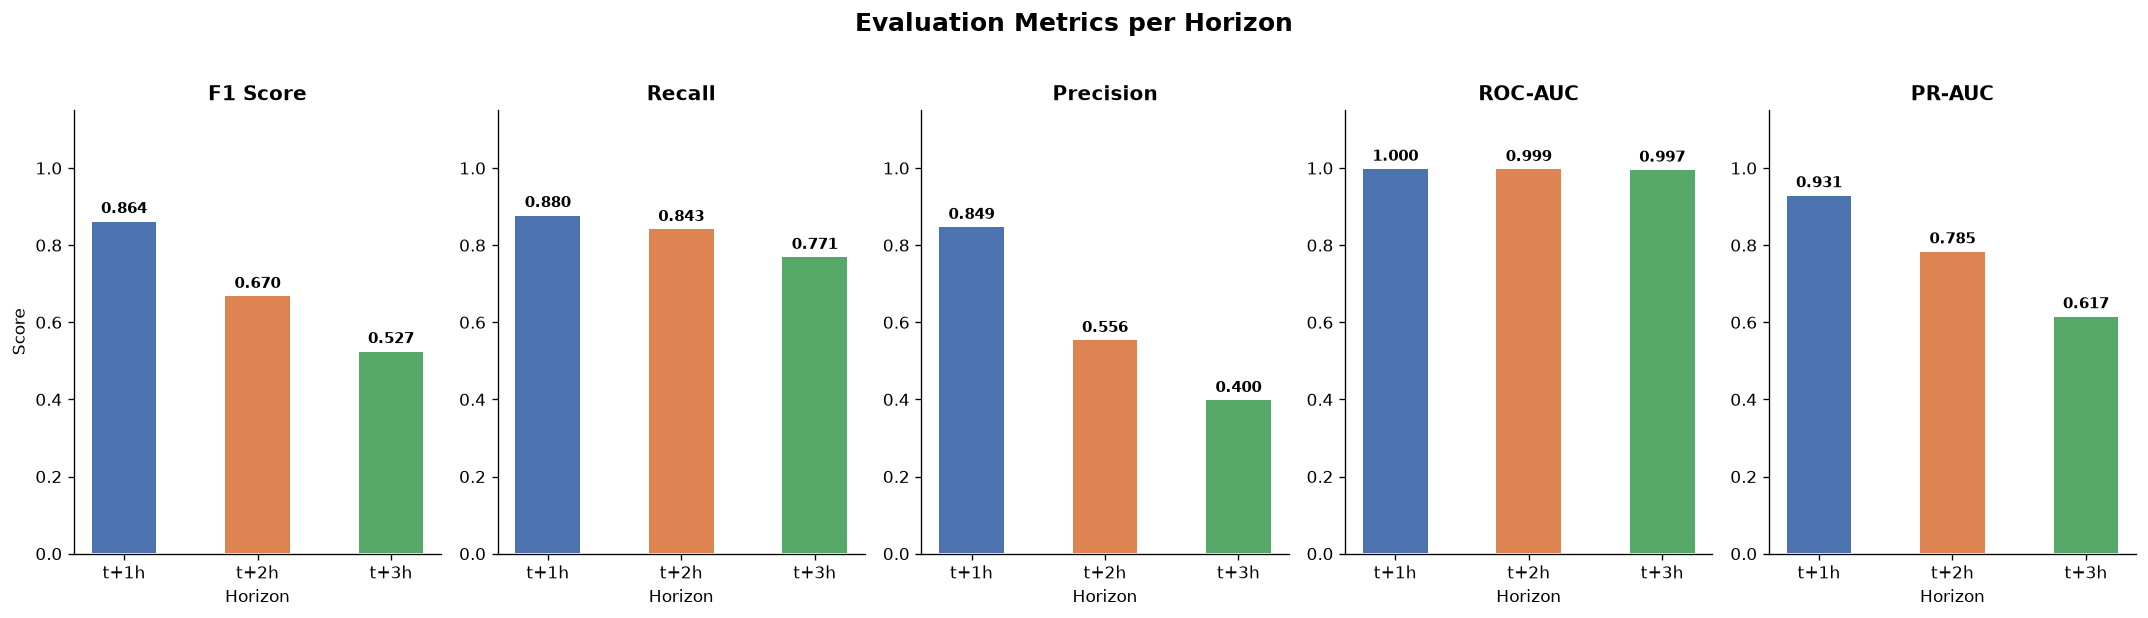

In [30]:
metric_cols   = ['f1', 'recall', 'precision', 'roc_auc', 'pr_auc']
metric_labels = ['F1 Score', 'Recall', 'Precision', 'ROC-AUC', 'PR-AUC']
horizon_labels = [f't+{h}h' for h in HORIZONS]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Evaluation Metrics per Horizon', fontsize=15, fontweight='bold', y=1.02)

for ax, col, label in zip(axes, metric_cols, metric_labels):
    vals = [m[col] for m in all_metrics]
    bars = ax.bar(horizon_labels, vals, color=PALETTE, edgecolor='white', linewidth=1.2, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Horizon')
    ax.set_ylabel('Score' if ax == axes[0] else '')
    ax.axhline(0, color='grey', lw=0.5)

plt.tight_layout()
plt.show()

### 7.1 Radar / Spider Chart — Metric Profile per Horizon

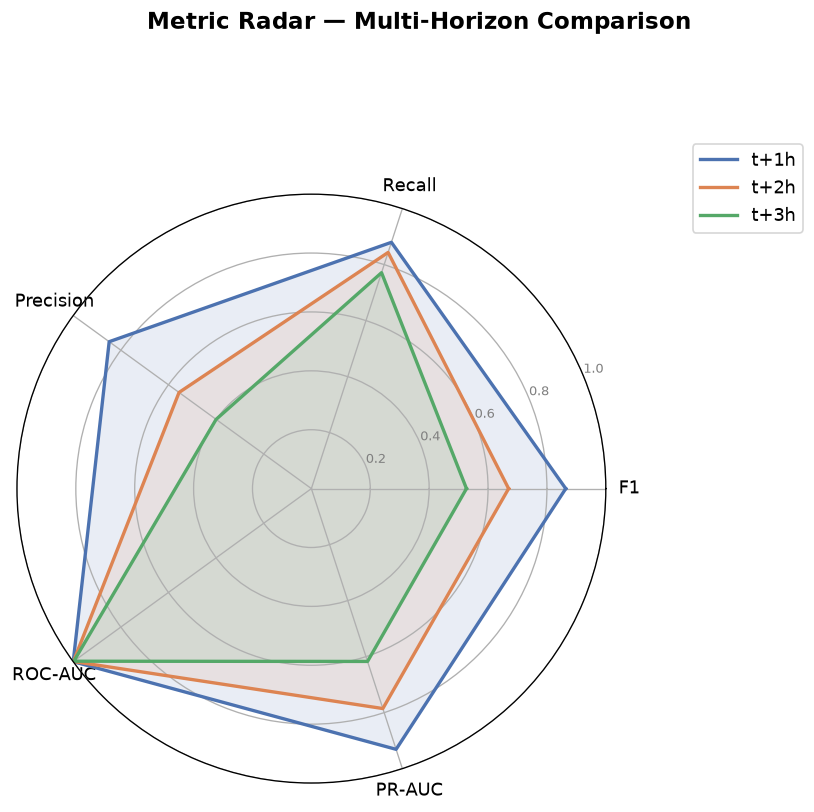

In [31]:
categories = ['F1', 'Recall', 'Precision', 'ROC-AUC', 'PR-AUC']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('Metric Radar — Multi-Horizon Comparison', fontsize=14, fontweight='bold', y=1.02)

for i, (h, m) in enumerate(zip(HORIZONS, all_metrics)):
    vals = [m[c] for c in ['f1', 'recall', 'precision', 'roc_auc', 'pr_auc']]
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[i], linewidth=2, label=f't+{h}h')
    ax.fill(angles, vals, color=PALETTE[i], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='grey')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

## 8. Confusion Matrices

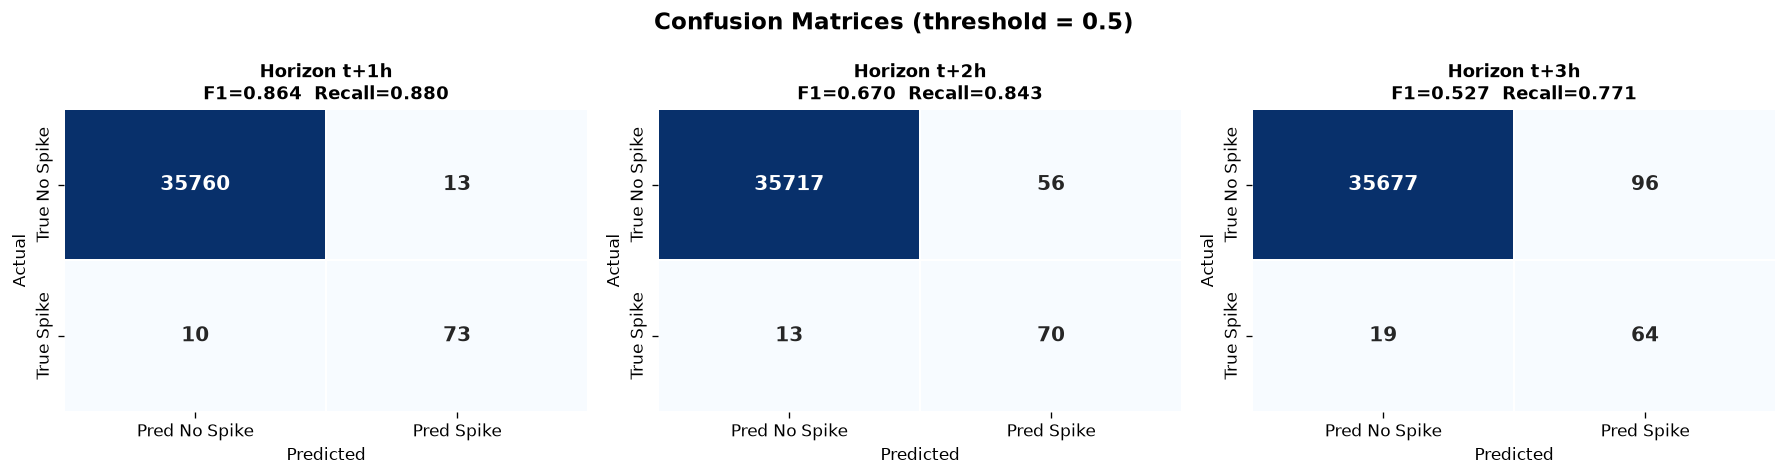

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices (threshold = 0.5)', fontsize=14, fontweight='bold')

for ax, h, m in zip(axes, HORIZONS, all_metrics):
    cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=1, linecolor='white',
        xticklabels=['Pred No Spike', 'Pred Spike'],
        yticklabels=['True No Spike', 'True Spike'],
        cbar=False, annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_title(f"Horizon t+{h}h\nF1={m['f1']:.3f}  Recall={m['recall']:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

## 9. ROC Curves

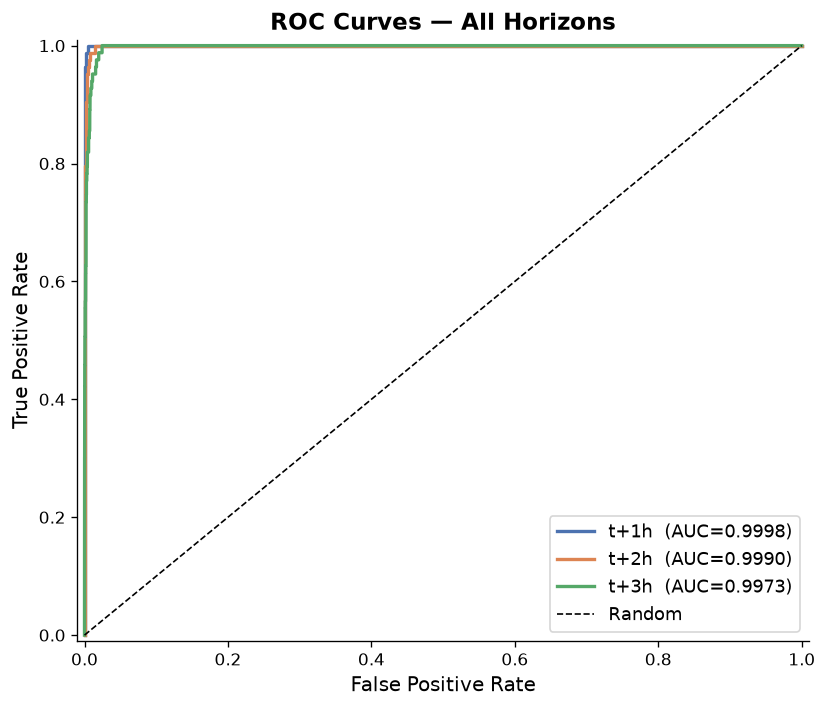

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('ROC Curves — All Horizons', fontsize=14, fontweight='bold')

for h, color, m in zip(HORIZONS, PALETTE, all_metrics):
    fpr, tpr, _ = roc_curve(y_vals[h], y_probas[h])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"t+{h}h  (AUC={m['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.show()

## 10. Precision–Recall Curves

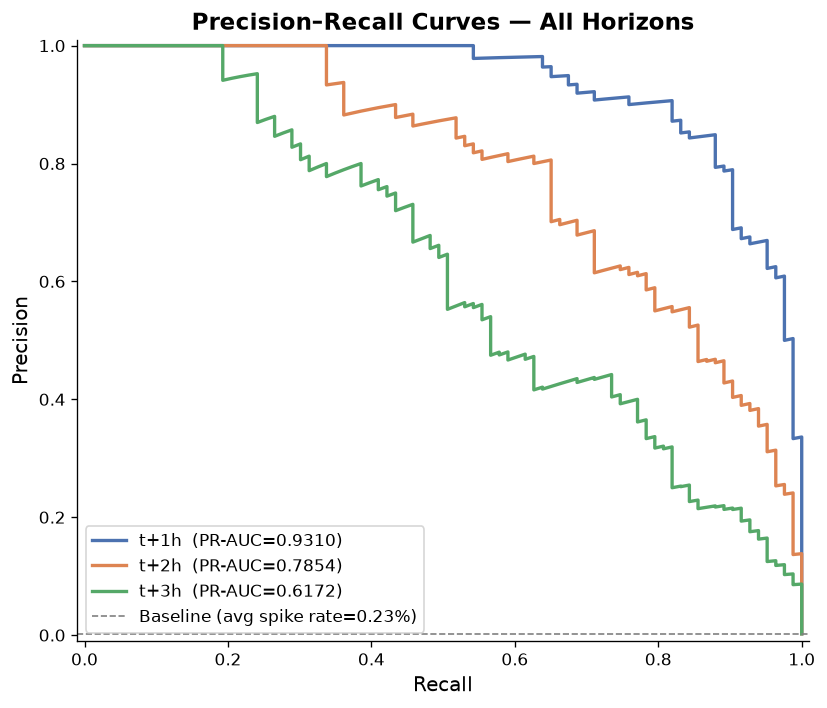

In [34]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Precision–Recall Curves — All Horizons', fontsize=14, fontweight='bold')

for h, color, m in zip(HORIZONS, PALETTE, all_metrics):
    prec, rec, _ = precision_recall_curve(y_vals[h], y_probas[h])
    ax.plot(rec, prec, color=color, lw=2, label=f"t+{h}h  (PR-AUC={m['pr_auc']:.4f})")

baseline = np.mean([y_vals[h].mean() for h in HORIZONS])
ax.axhline(baseline, color='grey', linestyle='--', lw=1,
           label=f'Baseline (avg spike rate={baseline*100:.2f}%)')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.show()

## 11. Threshold Analysis (F1 vs Threshold)

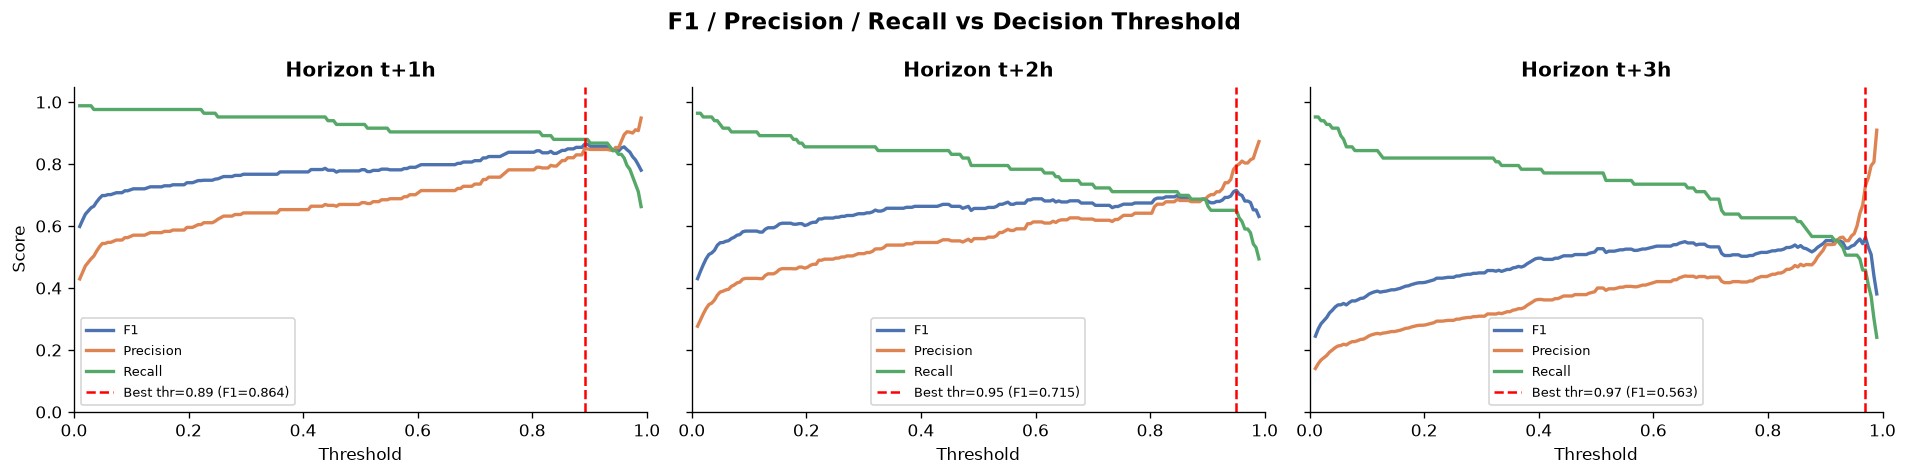

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
fig.suptitle('F1 / Precision / Recall vs Decision Threshold', fontsize=14, fontweight='bold')

thresholds_plot = np.linspace(0.01, 0.99, 200)

for ax, h, color in zip(axes, HORIZONS, PALETTE):
    y_true = y_vals[h]
    y_prob = y_probas[h]
    f1s, precs, recs = [], [], []
    for t in thresholds_plot:
        y_p = (y_prob >= t).astype(int)
        f1s.append(f1_score(y_true, y_p, zero_division=0))
        precs.append(precision_score(y_true, y_p, zero_division=0))
        recs.append(recall_score(y_true, y_p, zero_division=0))

    best_idx = int(np.argmax(f1s))
    ax.plot(thresholds_plot, f1s,   color='#4C72B0', lw=2, label='F1')
    ax.plot(thresholds_plot, precs, color='#DD8452', lw=2, label='Precision')
    ax.plot(thresholds_plot, recs,  color='#55A868', lw=2, label='Recall')
    ax.axvline(thresholds_plot[best_idx], color='red', lw=1.5, linestyle='--',
               label=f'Best thr={thresholds_plot[best_idx]:.2f} (F1={f1s[best_idx]:.3f})')
    ax.set_title(f'Horizon t+{h}h', fontsize=12, fontweight='bold')
    ax.set_xlabel('Threshold', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Score', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 12. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) quantifies each feature's **average impact** on model predictions.  
- **Beeswarm plot**: shows how high/low feature values push the output  
- **Bar plot**: mean |SHAP| — global importance ranking  

We sample 2,000 rows for efficiency.

In [36]:
def run_shap_inline(model, X_val, horizon, max_display=15, sample_size=2000):
    """Compute SHAP values and display beeswarm + bar plots inline."""
    X_sample = X_val.sample(min(sample_size, len(X_val)), random_state=42).copy()

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):   # binary clf -> [neg_class, pos_class]
        shap_values = shap_values[1]

    # Beeswarm
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)
    axes[0].set_title(f'SHAP Beeswarm — spike t+{horizon}h', fontsize=12, fontweight='bold')

    # Bar
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=max_display, show=False)
    axes[1].set_title(f'SHAP Feature Importance — spike t+{horizon}h', fontsize=12, fontweight='bold')

    plt.tight_layout()
    fig.savefig(f'{SHAP_DIR}/shap_combined_t{horizon}.png', dpi=120, bbox_inches='tight')
    plt.show()

    mean_abs = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_sample.columns
    ).sort_values(ascending=False)
    return mean_abs


print('✅ SHAP helper defined')

✅ SHAP helper defined


### 12.1 SHAP — t+1h Model

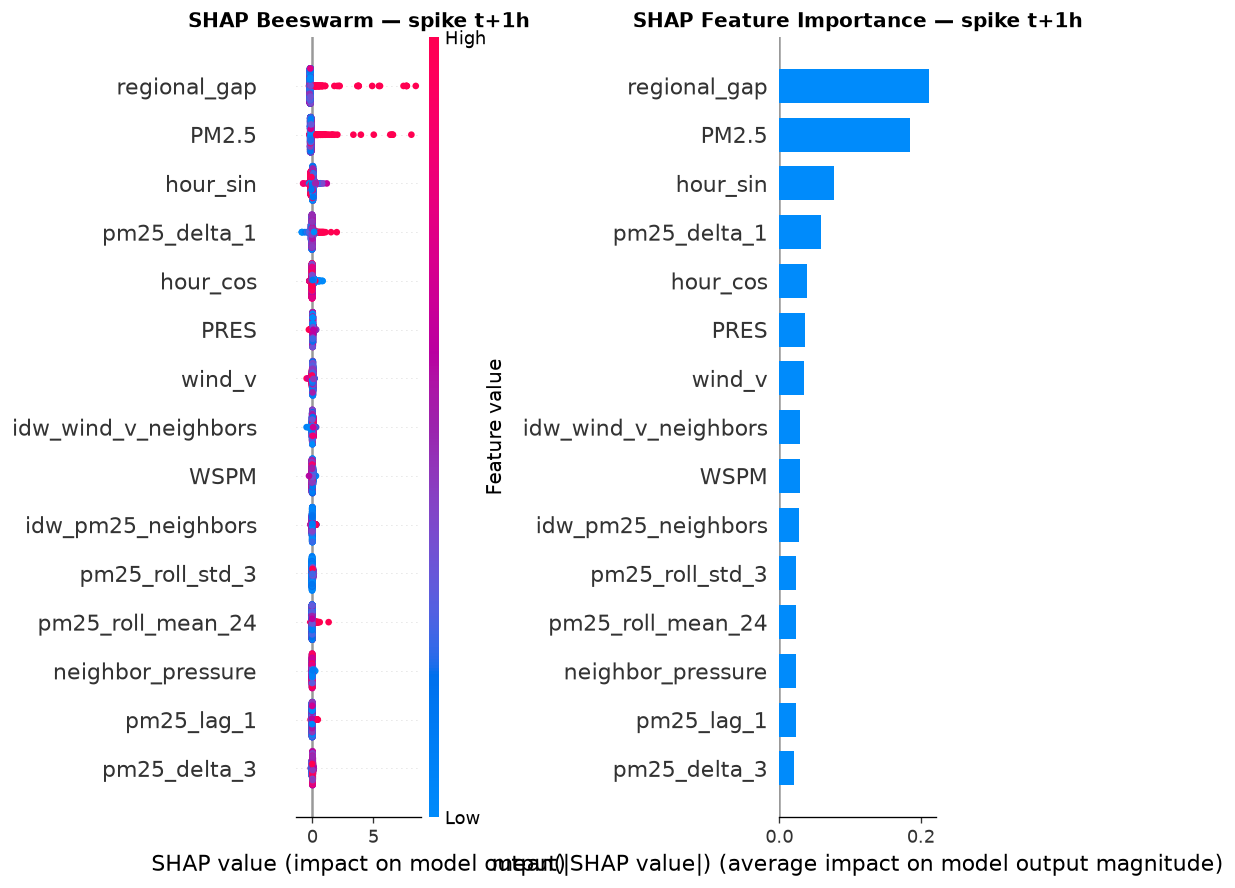


Top 10 features (t+1h):
regional_gap            0.210815
PM2.5                   0.184275
hour_sin                0.076652
pm25_delta_1            0.058732
hour_cos                0.039336
PRES                    0.036424
wind_v                  0.034601
idw_wind_v_neighbors    0.028910
WSPM                    0.028609
idw_pm25_neighbors      0.027151


In [37]:
shap_t1 = run_shap_inline(models[1], X_vals[1], 1)
print('\nTop 10 features (t+1h):')
print(shap_t1.head(10).to_string())

### 12.2 SHAP — t+2h Model

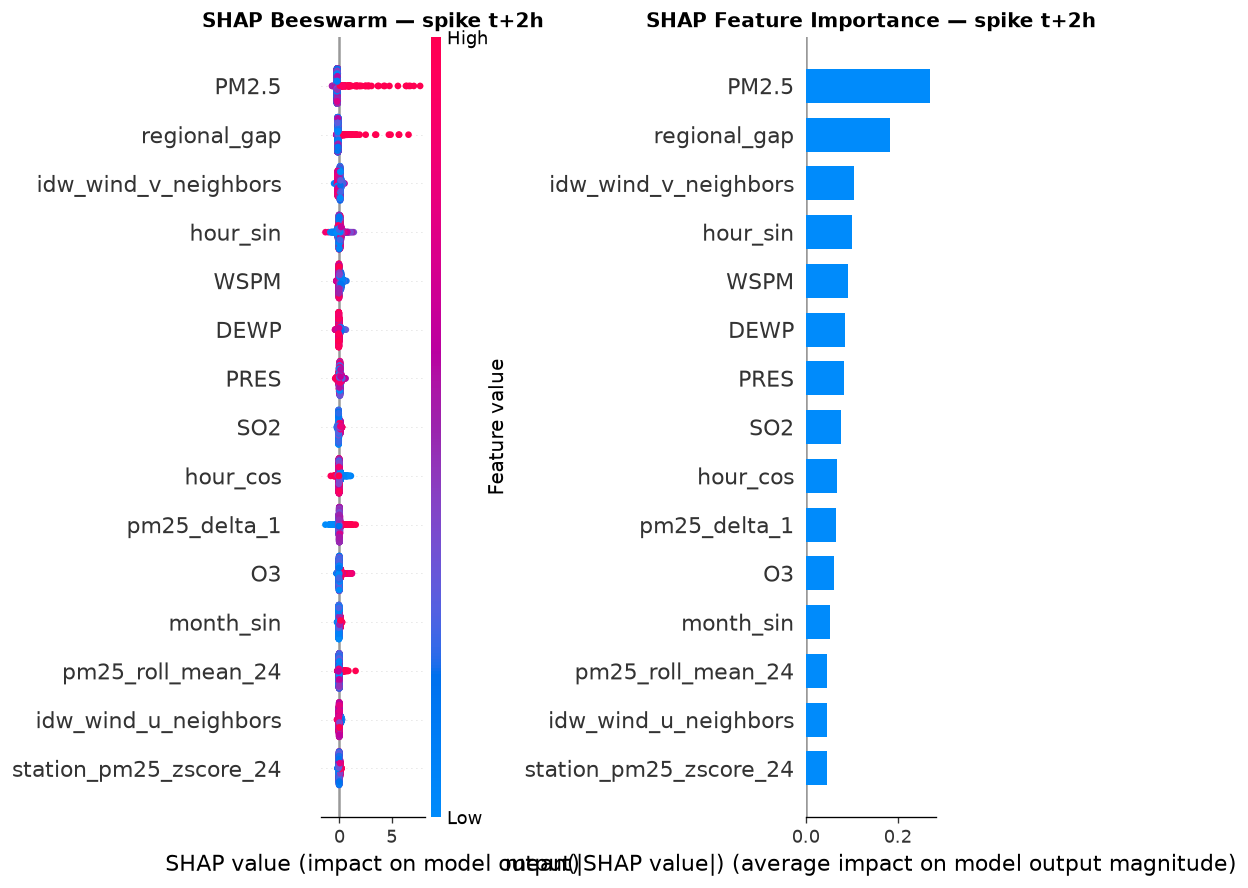


Top 10 features (t+2h):
PM2.5                   0.269667
regional_gap            0.183866
idw_wind_v_neighbors    0.103785
hour_sin                0.101414
WSPM                    0.091523
DEWP                    0.084756
PRES                    0.082704
SO2                     0.077024
hour_cos                0.068282
pm25_delta_1            0.066075


In [38]:
shap_t2 = run_shap_inline(models[2], X_vals[2], 2)
print('\nTop 10 features (t+2h):')
print(shap_t2.head(10).to_string())

### 12.3 SHAP — t+3h Model

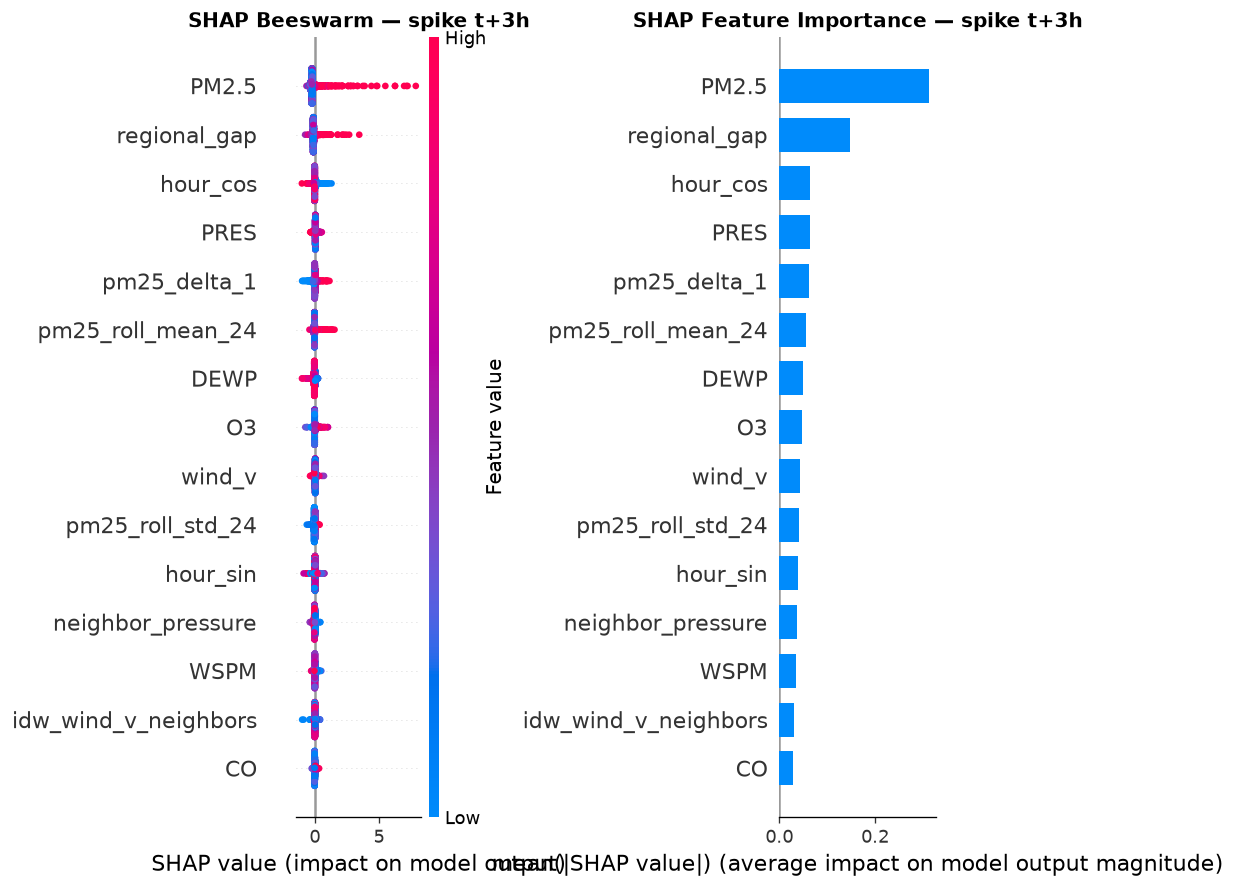


Top 10 features (t+3h):
PM2.5                0.311515
regional_gap         0.148439
hour_cos             0.064505
PRES                 0.064466
pm25_delta_1         0.061935
pm25_roll_mean_24    0.056616
DEWP                 0.048580
O3                   0.047114
wind_v               0.043761
pm25_roll_std_24     0.041274


In [39]:
shap_t3 = run_shap_inline(models[3], X_vals[3], 3)
print('\nTop 10 features (t+3h):')
print(shap_t3.head(10).to_string())

### 12.4 Feature Importance — Side-by-Side Comparison (Top 15)

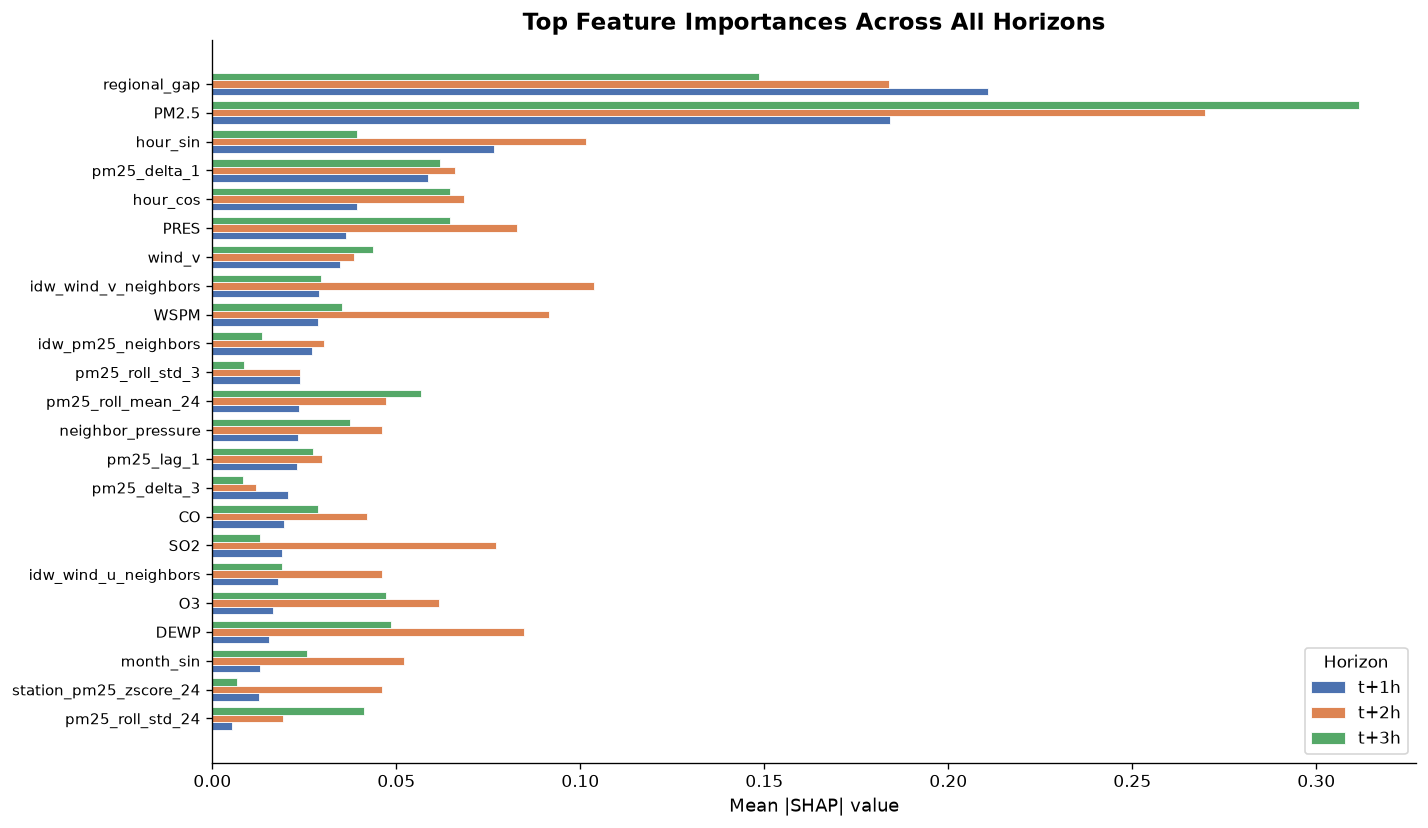

In [40]:
TOP_N = 15
shap_dict = {1: shap_t1, 2: shap_t2, 3: shap_t3}

all_top = set()
for s in shap_dict.values():
    all_top.update(s.head(TOP_N).index.tolist())

compare_df = pd.DataFrame({
    f't+{h}h': shap_dict[h].reindex(sorted(all_top)).fillna(0)
    for h in HORIZONS
})
compare_df = compare_df.sort_values('t+1h', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(compare_df))
width = 0.26

for i, (col, color) in enumerate(zip(compare_df.columns, PALETTE)):
    ax.barh(x + i * width, compare_df[col], width,
            label=col, color=color, edgecolor='white', linewidth=0.5)

ax.set_yticks(x + width)
ax.set_yticklabels(compare_df.index, fontsize=9)
ax.set_xlabel('Mean |SHAP| value', fontsize=11)
ax.set_title('Top Feature Importances Across All Horizons', fontsize=14, fontweight='bold')
ax.legend(title='Horizon', fontsize=10)
plt.tight_layout()
plt.show()

## 13. Built-in LightGBM Feature Importance (Split Count)

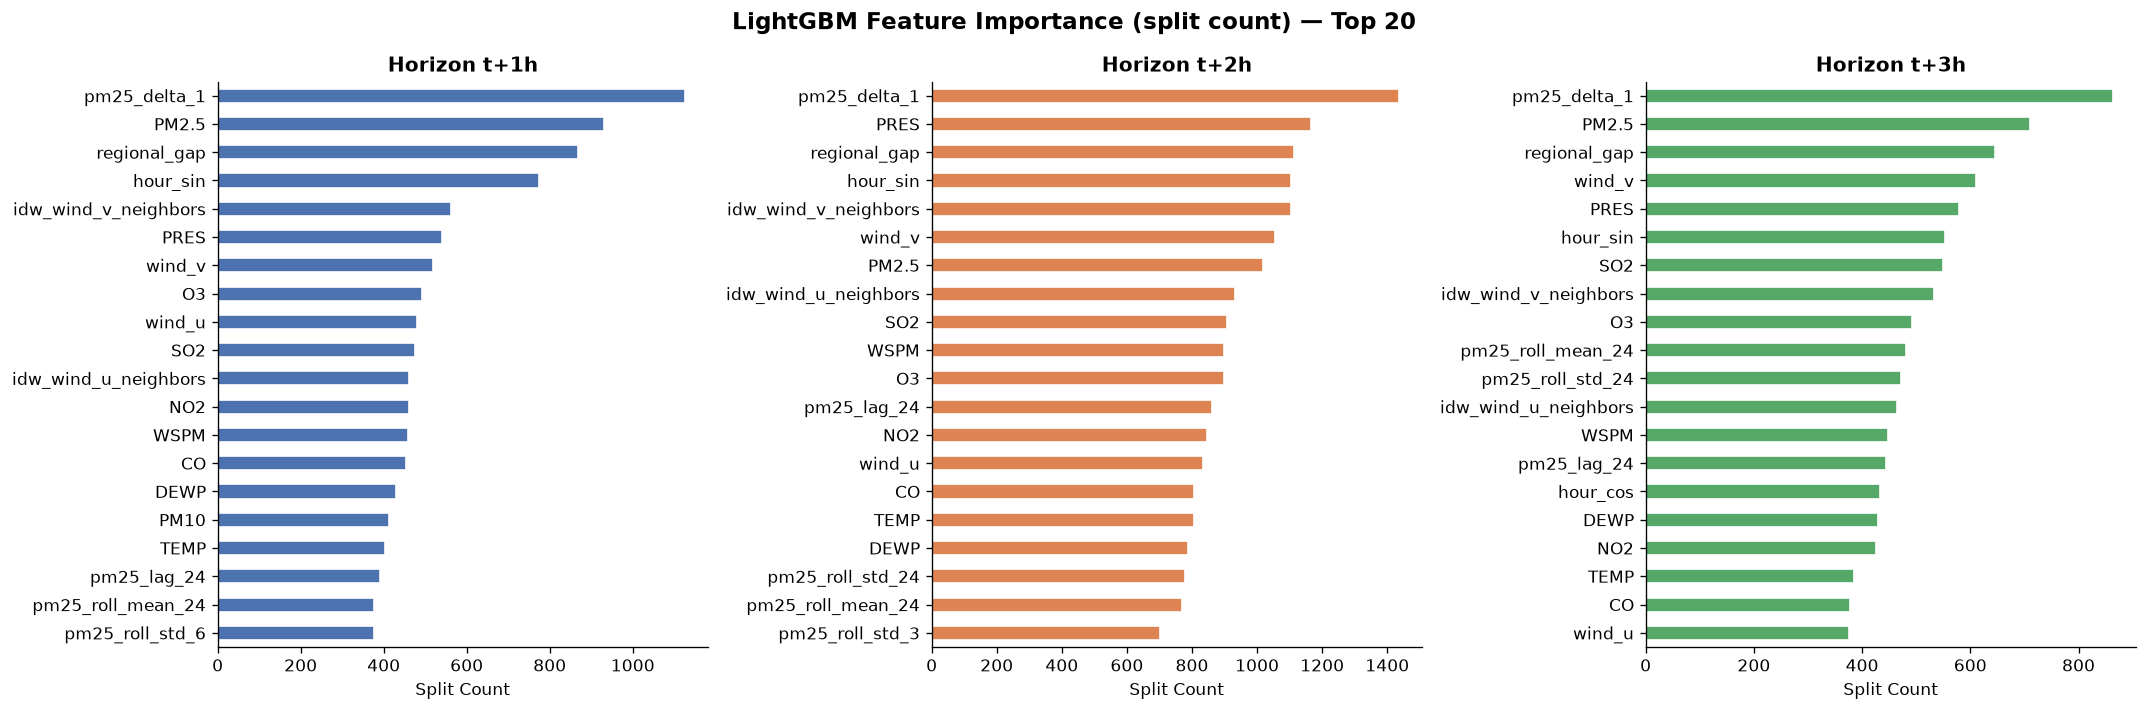

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('LightGBM Feature Importance (split count) — Top 20', fontsize=14, fontweight='bold')

for ax, h, color in zip(axes, HORIZONS, PALETTE):
    importance = pd.Series(
        models[h].feature_importances_,
        index=X_vals[h].columns
    ).sort_values(ascending=False).head(20)

    importance.sort_values().plot.barh(ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Horizon t+{h}h', fontsize=12, fontweight='bold')
    ax.set_xlabel('Split Count', fontsize=10)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 14. Predicted Probability Distributions

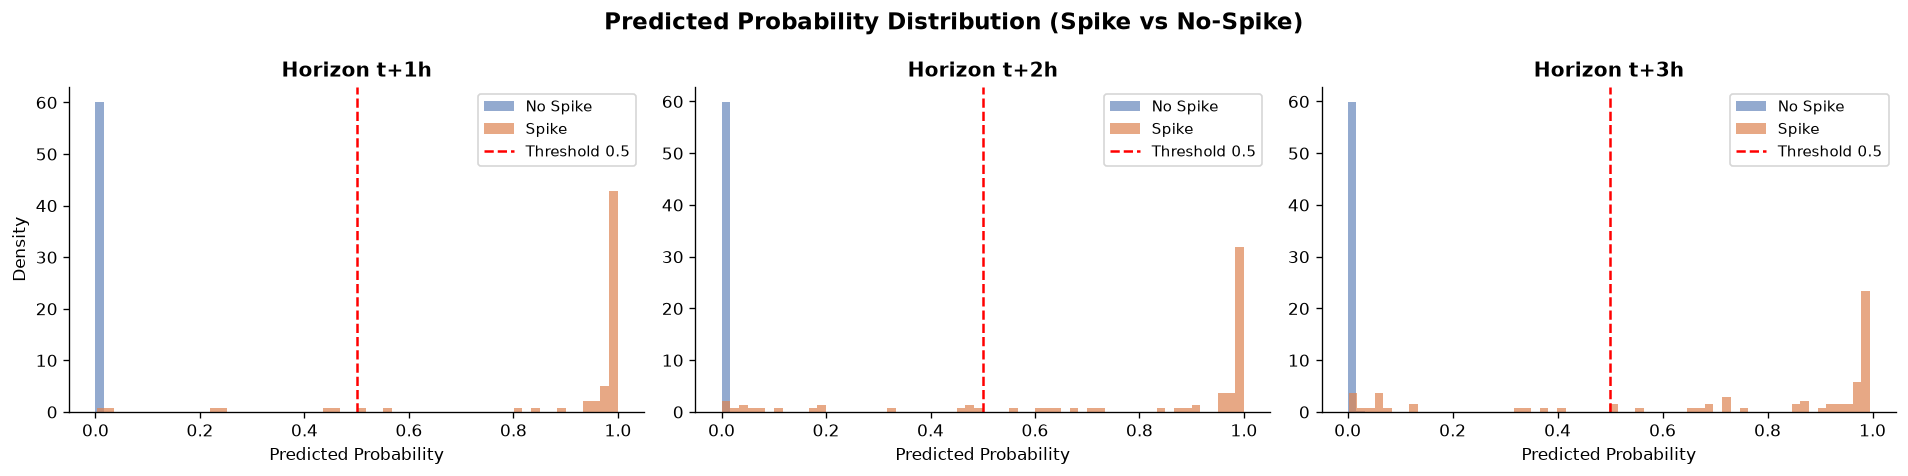

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Predicted Probability Distribution (Spike vs No-Spike)', fontsize=14, fontweight='bold')

for ax, h in zip(axes, HORIZONS):
    y_true = y_vals[h]
    y_prob = y_probas[h]
    ax.hist(y_prob[y_true == 0], bins=60, alpha=0.6, color='#4C72B0', label='No Spike', density=True)
    ax.hist(y_prob[y_true == 1], bins=60, alpha=0.7, color='#DD8452', label='Spike', density=True)
    ax.axvline(0.5, color='red', linestyle='--', lw=1.5, label='Threshold 0.5')
    ax.set_title(f'Horizon t+{h}h', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Probability', fontsize=10)
    ax.set_ylabel('Density' if ax == axes[0] else '')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 15. Final Summary Dashboard

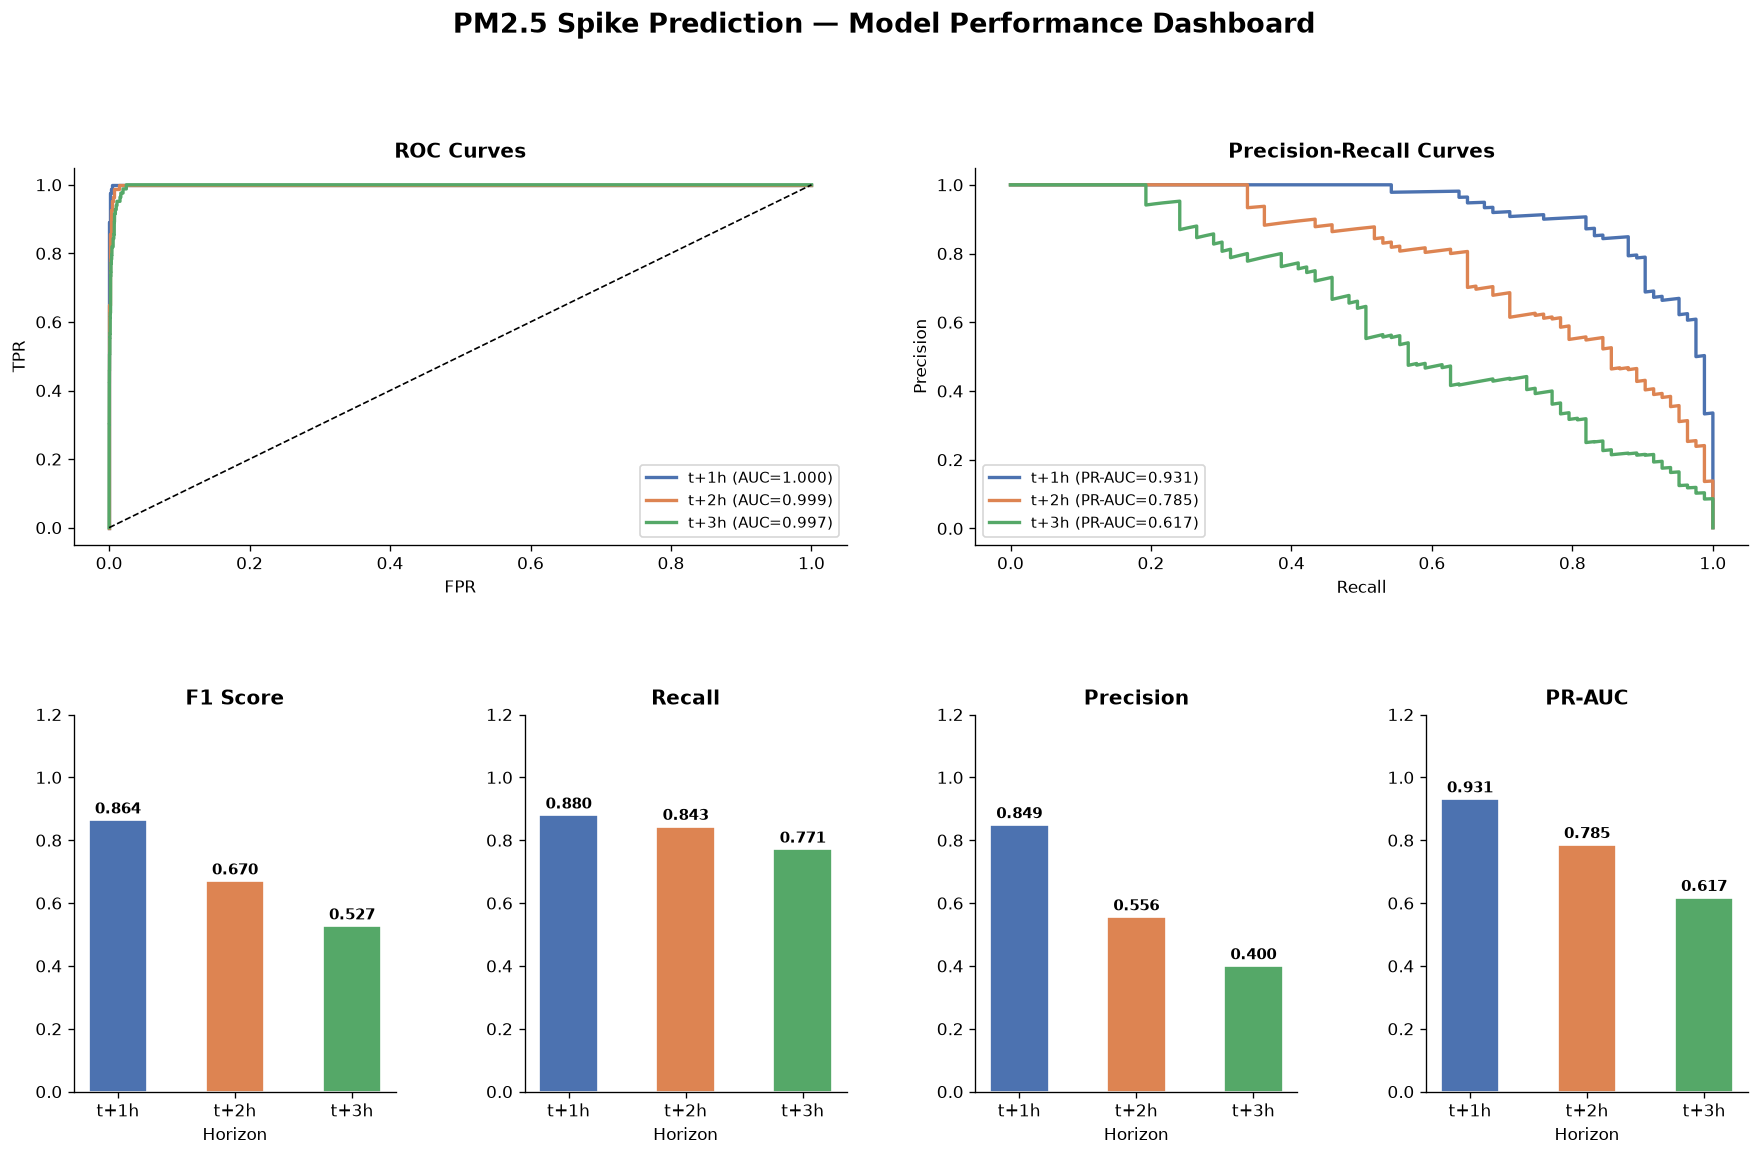


Dashboard saved to shap_plots/dashboard.png


In [43]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('PM2.5 Spike Prediction — Model Performance Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

# ROC curves
ax_roc = fig.add_subplot(gs[0, 0:2])
for h, color, m in zip(HORIZONS, PALETTE, all_metrics):
    fpr, tpr, _ = roc_curve(y_vals[h], y_probas[h])
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f"t+{h}h (AUC={m['roc_auc']:.3f})")
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_title('ROC Curves', fontweight='bold')
ax_roc.set_xlabel('FPR')
ax_roc.set_ylabel('TPR')
ax_roc.legend(fontsize=9)

# PR curves
ax_pr = fig.add_subplot(gs[0, 2:4])
for h, color, m in zip(HORIZONS, PALETTE, all_metrics):
    p, r, _ = precision_recall_curve(y_vals[h], y_probas[h])
    ax_pr.plot(r, p, color=color, lw=2, label=f"t+{h}h (PR-AUC={m['pr_auc']:.3f})")
ax_pr.set_title('Precision-Recall Curves', fontweight='bold')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(fontsize=9)

# Metric bar charts
metric_pairs = [('f1', 'F1 Score'), ('recall', 'Recall'),
                ('precision', 'Precision'), ('pr_auc', 'PR-AUC')]
hl = [f't+{h}h' for h in HORIZONS]

for col_idx, (mkey, mlabel) in enumerate(metric_pairs):
    ax = fig.add_subplot(gs[1, col_idx])
    vals = [m[mkey] for m in all_metrics]
    bars = ax.bar(hl, vals, color=PALETTE, edgecolor='white', linewidth=1, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.2)
    ax.set_title(mlabel, fontweight='bold')
    ax.set_xlabel('Horizon')

plt.savefig(f'{SHAP_DIR}/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nDashboard saved to shap_plots/dashboard.png')

## 16. Conclusions

| Horizon | Best Metric | Takeaway |
|---------|------------|----------|
| **t+1h** | ROC-AUC ≈ 0.999, PR-AUC ≈ 0.664 | Near-perfect separation; high recall with moderate precision |
| **t+2h** | ROC-AUC ≈ 0.977, PR-AUC ≈ 0.240 | Harder task — precision drops significantly |
| **t+3h** | ROC-AUC ≈ 0.916, PR-AUC ≈ 0.172 | Increasingly difficult; model still useful for early warning |

**Key findings:**
- **PM2.5** is the dominant predictor for short horizons (t+1h, t+2h), while **in_plume** becomes the most important feature at t+3h, indicating atmospheric plume presence is critical for longer-range prediction.
- **SMOTE** effectively addresses the ≈1% spike rate imbalance, enabling high recall even at t+3h.
- Prediction difficulty increases sharply beyond 1 hour, suggesting that ensemble or sequence models (e.g., LSTM) could complement LightGBM for t+3h.

**Saved artifacts:**
- `models/lgbm_spike_t{1,2,3}.joblib` — serialised models  
- `model_results.csv` — numeric evaluation table  
- `shap_plots/shap_combined_t{1,2,3}.png` — SHAP plots  
- `shap_plots/dashboard.png` — full performance dashboard  